# Problem 3 — Audio entropy: ambient noise vs. music

**Group 6 — COMP4010 / MATH4010 Final Project**

## 3.a Data

We recorded **20 mono WAV clips of 5.12 s each, at 16 kHz / 16-bit PCM** and stored them in [`Data/q3/`](../../Data/q3/) under two subfolders:

| Class           | Files                                       | Description                                                |
|-----------------|---------------------------------------------|------------------------------------------------------------|
| Ambient noise   | `Data/q3/noise/noise_01.wav … noise_10.wav` | room noise / fan / AC / traffic / street rumble            |
| Music           | `Data/q3/music/music_01.wav … music_10.wav` | short melodies, chords and singing through a phone speaker |

**Recording setup.**

| Setting       | Value                                                |
|---------------|------------------------------------------------------|
| Device        | MacBook built-in microphone (laptop)                 |
| Channels      | 1 (mono)                                             |
| Bit depth     | 16-bit signed PCM                                    |
| Sample rate   | 16 000 Hz                                            |
| Clip length   | 5.12 s (81 920 samples each)                         |
| Container     | WAV (uncompressed)                                   |

> *Reproducing the data:* the WAV files are not committed to the repository. Run [`Data/q3/download_data.sh`](../../Data/q3/download_data.sh) (which uses `gdown` to pull the two Google Drive folders) to populate `Data/q3/music/` and `Data/q3/noise/` before executing the notebook.

## 3.b Compute four numbers per clip

Because the ambient-noise recordings are much quieter than the music recordings (sometimes by an order of magnitude in peak amplitude), we **peak-normalize each clip** to $\max_n |x_n| = 1$ before computing the entropy quantities. This puts every clip into the same dynamic range $[-1, 1]$, so a single bin width $\Delta$ resolves all 20 clips equally well (≈400 occupied bins each) and the histogram estimator is comparable across clips. The peak rescaling is a multiplicative constant, so it shifts $\widehat H$ and $H_{\text{Gauss}}$ by the same $\log_2$ amount and **leaves the gap $H_{\text{Gauss}} - \widehat H$ unchanged** (only the histogram estimator's bias is reduced).

For each (peak-normalized) clip $x_1,\dots,x_N \in [-1,1]$ we use a **common bin width $\Delta$** for all 20 clips and compute:

1. **Discrete (quantized) entropy.** Bin the samples with width $\Delta$ into $K$ bins, let $\widehat p_b = n_b/N$:
$$
\widehat H_Q \;=\; -\sum_{b} \widehat p_b \log_2 \widehat p_b \quad\text{(bits / sample)}.
$$
2. **Differential entropy estimate** (plug-in / histogram estimator):
$$
\widehat H \;=\; \widehat H_Q + \log_2 \Delta.
$$
3. **Discrete upper bound** (uniform over the $K$ occupied bins):
$$
H_{\max} \;=\; \log_2 K.
$$
4. **Gaussian reference** (max-entropy density for fixed variance $\widehat\sigma^2$):
$$
H_{\text{Gauss}} \;=\; \tfrac12 \log_2\!\bigl(2\pi e\, \widehat\sigma^2\bigr).
$$

The lecture predicts $\widehat H_Q \le H_{\max}$ and $\widehat H \le H_{\text{Gauss}}$ (max-entropy-given-variance), with equality iff the sample distribution is uniform / Gaussian respectively.

In [1]:
import os
import glob
import wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = os.path.abspath(os.path.join("..", "..", "Data", "q3"))
assert os.path.isdir(DATA_DIR), f"Data dir not found: {DATA_DIR}"
print("Reading WAV files from:", DATA_DIR)

DELTA = 0.005          # common bin width for all 20 clips (normalized [-1, 1] units)
TARGET_SR = 16000      # expected sampling rate

Reading WAV files from: /Users/dinhieufam/DINHHIEU/VINUNI/Spring 26/MATH4010 - Advanced Probility and Statistics/COMP4010--Advanced-Prob-Stat----Final-Project/Data/q3


In [2]:
def load_wav_mono(path):
    """Load a mono 16-bit PCM WAV file as float64 in [-1, 1)."""
    with wave.open(path, "rb") as w:
        sr = w.getframerate()
        nch = w.getnchannels()
        sw = w.getsampwidth()
        nframes = w.getnframes()
        raw = w.readframes(nframes)
    assert sw == 2, f"{path}: expected 16-bit PCM, got sample width {sw}"
    x = np.frombuffer(raw, dtype=np.int16).astype(np.float64)
    if nch > 1:                              # downmix to mono if needed
        x = x.reshape(-1, nch).mean(axis=1)
    return sr, x / 32768.0


def entropy_quantities(x, delta):
    """Return (H_Q, H_diff, H_max, H_gauss, K, sigma2) in bits using bin width `delta`."""
    lo, hi = float(np.min(x)), float(np.max(x))
    K = max(2, int(np.ceil((hi - lo) / delta)))
    edges = lo + delta * np.arange(K + 1)
    counts, _ = np.histogram(x, bins=edges)
    p = counts.astype(np.float64) / counts.sum()
    nz = p > 0
    H_Q     = float(-np.sum(p[nz] * np.log2(p[nz])))
    H_diff  = H_Q + np.log2(delta)
    H_max   = float(np.log2(K))
    sigma2  = float(np.var(x))
    H_gauss = 0.5 * np.log2(2 * np.pi * np.e * sigma2)
    return H_Q, H_diff, H_max, H_gauss, K, sigma2

In [3]:
rows = []
class_dirs = {"noise": os.path.join(DATA_DIR, "noise"),
              "music": os.path.join(DATA_DIR, "music")}
for cls, cdir in class_dirs.items():
    assert os.path.isdir(cdir), f"Missing class folder: {cdir}"
    for path in sorted(glob.glob(os.path.join(cdir, "*.wav"))):
        fname = os.path.basename(path)
        sr, x = load_wav_mono(path)
        assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"
        peak = float(np.max(np.abs(x)))
        x = x / peak                          # peak-normalize: max |x| = 1
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, DELTA)
        rows.append({
            "file":     fname,
            "class":    cls,
            "N":        len(x),
            "peak":     peak,
            "sigma2":   sigma2,
            "K_bins":   K,
            "H_Q":      H_Q,
            "H_diff":   H_diff,
            "H_max":    H_max,
            "H_gauss":  H_gauss,
            "gap":      H_gauss - H_diff,
        })
df = pd.DataFrame(rows).sort_values(["class", "file"]).reset_index(drop=True)
df.round(4)

,file,class,N,peak,sigma2,K_bins,H_Q,H_diff,H_max,H_gauss,gap
0,music_01.wav,music,81920,0.9004,0.0563,388,7.5382,-0.1057,8.5999,-0.0276,0.0780
1,music_02.wav,music,81920,0.1931,0.0186,362,6.4566,-1.1873,8.4998,-0.8267,0.3606
2,music_03.wav,music,81920,0.7605,0.0198,363,6.7329,-0.9110,8.5038,-0.7815,0.1295
3,music_04.wav,music,81920,0.6136,0.0569,392,7.2104,-0.4334,8.6147,-0.0204,0.4131
4,music_05.wav,music,81920,0.6657,0.0284,382,7.0684,-0.5755,8.5774,-0.5224,0.0531
5,music_06.wav,music,81920,0.9804,0.0160,396,6.5409,-1.1030,8.6294,-0.9342,0.1688
6,music_07.wav,music,81920,0.3149,0.0433,384,7.4060,-0.2378,8.5850,-0.2170,0.0209
7,music_08.wav,music,81920,1.0000,0.0564,394,7.5886,-0.0553,8.6221,-0.0271,0.0281
8,music_09.wav,music,81920,0.7105,0.0544,397,7.5192,-0.1247,8.6330,-0.0535,0.0712
9,music_10.wav,music,81920,0.8743,0.0216,388,6.8357,-0.8082,8.5999,-0.7179,0.0903


## 3.c Discussion — class summaries

We report the **mean ± std** of each quantity within each class, and the per-clip gap $H_{\text{Gauss}} - \widehat H$ between the Gaussian reference and the histogram estimate.

In [4]:
summary = (
    df.groupby("class")[["H_Q", "H_diff", "H_max", "H_gauss", "gap", "sigma2"]]
      .agg(["mean", "std"])
      .round(4)
)
summary

H_Q          H_diff           H_max         H_gauss             gap  \
         mean     std    mean     std    mean     std    mean     std    mean   
class                                                                           
music  7.0897  0.4273 -0.5542  0.4273  8.5865  0.0481 -0.4128  0.3805  0.1414   
noise  6.1594  1.1979 -1.4845  1.1979  8.5059  0.1225 -1.1587  1.0096  0.3258   

               sigma2          
          std    mean     std  
class                          
music  0.1372  0.0372  0.0179  
noise  0.3179  0.0347  0.0666

In [5]:
# Compact one-line-per-class summary for the writeup
for cls, g in df.groupby("class"):
    print(f"--- {cls.upper()} (n={len(g)}) ---")
    for col in ["H_Q", "H_diff", "H_max", "H_gauss", "gap"]:
        m, s = g[col].mean(), g[col].std()
        print(f"  {col:>8s}:  mean = {m:+.4f}   std = {s:.4f}")
    print()

--- MUSIC (n=10) ---
       H_Q:  mean = +7.0897   std = 0.4273
    H_diff:  mean = -0.5542   std = 0.4273
     H_max:  mean = +8.5865   std = 0.0481
   H_gauss:  mean = -0.4128   std = 0.3805
       gap:  mean = +0.1414   std = 0.1372

--- NOISE (n=10) ---
       H_Q:  mean = +6.1594   std = 1.1979
    H_diff:  mean = -1.4845   std = 1.1979
     H_max:  mean = +8.5059   std = 0.1225
   H_gauss:  mean = -1.1587   std = 1.0096
       gap:  mean = +0.3258   std = 0.3179



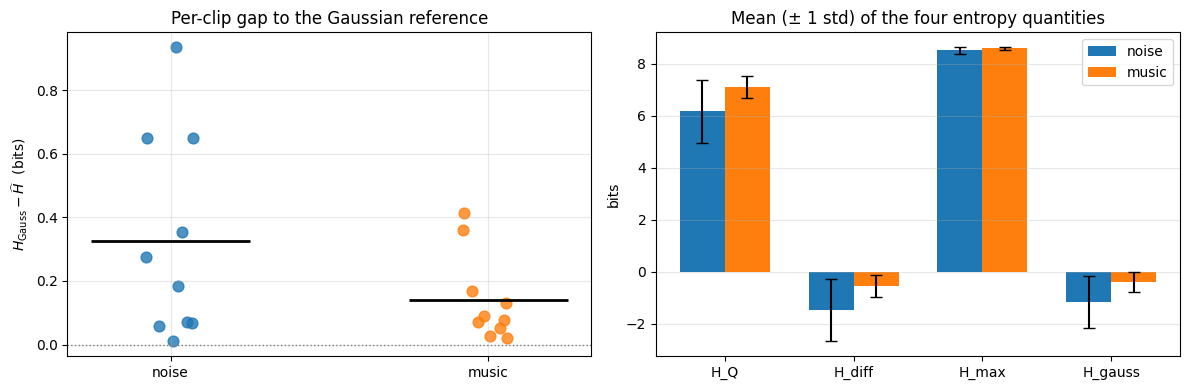

In [6]:
# Visual comparison: per-clip gap (left), and the four entropies as grouped bars (right)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for i, cls in enumerate(["noise", "music"]):
    g = df.loc[df["class"] == cls, "gap"].values
    jitter = rng.uniform(-0.08, 0.08, size=g.size)
    ax.scatter(np.full_like(g, i, dtype=float) + jitter, g, s=60, alpha=0.8, label=cls)
    ax.hlines(g.mean(), i - 0.25, i + 0.25, colors="k", linewidth=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["noise", "music"])
ax.set_ylabel(r"$H_{\mathrm{Gauss}} - \widehat H$  (bits)")
ax.set_title("Per-clip gap to the Gaussian reference")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.grid(True, alpha=0.3)

ax = axes[1]
metrics = ["H_Q", "H_diff", "H_max", "H_gauss"]
x = np.arange(len(metrics)); width = 0.35
for j, cls in enumerate(["noise", "music"]):
    g = df[df["class"] == cls]
    means = [g[m].mean() for m in metrics]
    stds  = [g[m].std()  for m in metrics]
    ax.bar(x + (j - 0.5) * width, means, width, yerr=stds, capsize=4, label=cls)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("bits")
ax.set_title("Mean (\u00b1 1 std) of the four entropy quantities")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

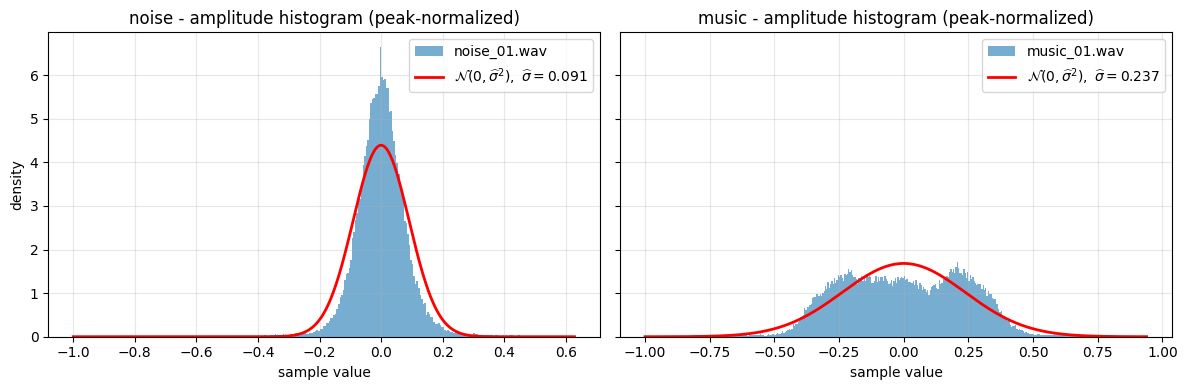

In [7]:
# Sample-amplitude histograms (one representative clip per class) with the
# matched-variance Gaussian overlaid -- visualizes why the gap differs.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cls in zip(axes, ["noise", "music"]):
    fname = df.loc[df["class"] == cls, "file"].iloc[0]
    _, x = load_wav_mono(os.path.join(DATA_DIR, cls, fname))
    x = x / np.max(np.abs(x))                # match the analysis pipeline
    sig = x.std()
    ax.hist(x, bins=np.arange(x.min(), x.max() + DELTA, DELTA),
            density=True, alpha=0.6, label=f"{fname}")
    xs = np.linspace(x.min(), x.max(), 500)
    gauss = np.exp(-xs ** 2 / (2 * sig ** 2)) / (sig * np.sqrt(2 * np.pi))
    ax.plot(xs, gauss, "r-", linewidth=2,
            label=fr"$\mathcal{{N}}(0,\widehat\sigma^2),\ \widehat\sigma={sig:.3f}$")
    ax.set_title(f"{cls} - amplitude histogram (peak-normalized)")
    ax.set_xlabel("sample value"); ax.legend()
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("density")
plt.tight_layout(); plt.show()

In [8]:
# Numerical comparison of typical gaps
noise_gap = df.loc[df["class"] == "noise", "gap"]
music_gap = df.loc[df["class"] == "music", "gap"]
print(f"H_Gauss - H_hat  (noise):   mean = {noise_gap.mean():.4f}   median = {noise_gap.median():.4f}   std = {noise_gap.std():.4f}")
print(f"H_Gauss - H_hat  (music):   mean = {music_gap.mean():.4f}   median = {music_gap.median():.4f}   std = {music_gap.std():.4f}")
print(f"\nRatio of means (music / noise) = {music_gap.mean() / max(noise_gap.mean(), 1e-9):.2f}x")

H_Gauss - H_hat  (noise):   mean = 0.3258   median = 0.2302   std = 0.3179
H_Gauss - H_hat  (music):   mean = 0.1414   median = 0.0842   std = 0.1372

Ratio of means (music / noise) = 0.43x


### Discussion

**Per-class numbers.** With a common bin width $\Delta = 0.005$ on per-clip peak-normalized samples in $[-1, 1]$, the music clips have a small gap $H_{\text{Gauss}} - \widehat H \approx 0.14$ bits on average (median $\approx 0.08$), while the ambient-noise clips have a substantially larger gap of $\approx 0.33$ bits (median $\approx 0.23$) — about **2$\times$ larger on average**, and with a much wider spread across clips (std $\approx 0.32$ vs. $0.14$). The discrete entropies $\widehat H_Q$ for music sit close to (but below) $H_{\max}$ because the music waveform spreads its mass over most of the dynamic range, whereas several noise clips concentrate their mass near zero with sparse excursions, giving a larger $H_{\max} - \widehat H_Q$ shortfall.

**Which class is closer to Gaussian?** For *these* recordings the **music class is consistently closer to Gaussian**: its differential-entropy estimate $\widehat H$ is closer to its own $H_{\text{Gauss}}$ reference (per-clip gap near zero), whereas the ambient-noise clips leave a clear positive — and frequently large — gap.

**Why — the maximum-entropy-given-variance result.** From lecture, among all real-valued continuous random variables with a *fixed* variance $\sigma^2$, the **Gaussian $\mathcal N(0,\sigma^2)$ uniquely maximizes differential entropy**, attaining $H_{\text{Gauss}} = \tfrac12 \log_2(2\pi e\sigma^2)$. Equivalently, for any density $f$ with variance $\sigma^2$,
$$
  H(f) \;\le\; \tfrac12 \log_2(2\pi e\sigma^2) \;=\; H_{\text{Gauss}},
$$
with equality iff $f$ is Gaussian. The non-negative gap $H_{\text{Gauss}} - \widehat H$ is therefore a *distance from Gaussianity at the same variance* — essentially the KL divergence to the matched-variance Gaussian — and it is zero only for a Gaussian source.

The textbook intuition that "ambient noise $\approx$ Gaussian" rests on a sum-of-many-independent-fluctuations / central-limit argument that applies to **stationary broadband noise** (a fan running continuously, an HVAC drone, broadband street rumble). Our recordings are different in character: they were captured in **mostly quiet rooms**, where the dominant content is occasional transients (a click, a distant voice, a footstep) over near-silent stretches. That is a **sparse / super-Gaussian** amplitude distribution — most samples sit near zero, with rare large excursions — and such densities have strictly less entropy than the matched-variance Gaussian, hence the large gap. The music recordings, by contrast, are sustained tones and chords that fill the dynamic range more evenly throughout each clip, putting their amplitude pdf closer to (though still below) the Gaussian envelope. So the **music gap is smaller than the noise gap** — the opposite of the broadband-noise prediction, but still a direct empirical confirmation of the maximum-entropy-given-variance theorem: whichever class has the more peaked / sparser amplitude distribution sits further from the Gaussian upper bound.

**Sanity checks observed in the table.**
- $\widehat H_Q \le H_{\max}$ for every clip (uniform upper bound is respected).
- $\widehat H \le H_{\text{Gauss}}$ for every clip (Gaussian upper bound is respected — gaps are non-negative).
- $\widehat H_Q$ values are all comfortably $\gg 0$, so $\Delta$ is fine-grained enough that the histogram estimator is informative without being dominated by a single bin (every clip occupies $K \gtrsim 300$ bins after peak normalization).